In [3]:
#For jum002 HPC setup
import sys
sys.path.append("/home/jum002/store7/repo/snowmicropyn")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
from scipy.stats import linregress


# #local import
import akross_common_functions as AK

# #SMRT import
from smrt.permittivity.saline_snow import saline_snow_permittivity_scharien_with_stogryn95 as ssp
from smrt import make_model
from smrt.inputs import altimeter_list
from smrt.emmodel.iba import derived_IBA


#turn off warning
import warnings
warnings.simplefilter('ignore')
pd.set_option('mode.chained_assignment',None)

This notebook contains the following 4 sections

1. Align observation of waveform
2. prepare snowpack for simulation
3. Normalisation factor and roughness optimization
4. Simulation and observation comparison

### 1. Align Observation of Waveform

Import observation form pickle file and align to nominal gate of simulation.

In [5]:
#get obs
obs_CB = pd.read_pickle('smrt_in-out/observed_waveform_CB')
obs_E22 = pd.read_pickle('smrt_in-out/observed_waveform_E22')
obs_E16 = pd.read_pickle('smrt_in-out/observed_waveform_E16')
obs_A = pd.read_pickle('smrt_in-out/observed_waveform_A')

#get mean waveform
mean_obs_CB = obs_CB['mean']
mean_obs_E22 = obs_E22['mean']
mean_obs_E = obs_E16['mean']
mean_obs_A = obs_A['mean']

### 2. Prepare snowpack for simulation

- import profile derived from smp ready to input in SMRT simulation
-  pickle file of profile already prepare for input for SMRT. Pre processing was done to put smp density, ssa with temperature and salinity from pit.

In [6]:
#Get smp from Eureka22
list_profile_E22 = pd.read_pickle('smrt_in-out/smp_profile_E22_3cm')
#get smp profile for CB
list_profile_CB = pd.read_pickle('smrt_in-out/smp_profile_CB_3cm')

# create list of SMRT snpwpack
CB_sp_1 = AK.build_snowpack_pickle(list_profile_CB, ice_salinity = 10, ice_temp = 260, sea_ice_density = 910, 
                                    ice_type = 'firstyear', sigma_surface= 0.1)
CB_sp_2 = AK.build_snowpack_pickle(list_profile_CB, ice_salinity = 10, ice_temp = 260, sea_ice_density = 910, 
                                    ice_type = 'firstyear', sigma_surface= 0.3)
CB_sp_3 = AK.build_snowpack_pickle(list_profile_CB, ice_salinity = 10, ice_temp = 260, sea_ice_density = 910, 
                                    ice_type = 'firstyear', sigma_surface= 0.6)

E22_sp_1 = AK.build_snowpack_pickle(list_profile_E22, ice_salinity = 10, ice_temp = 260, sea_ice_density = 910, 
                                    ice_type = 'firstyear', sigma_surface= 0.1)
E22_sp_2 = AK.build_snowpack_pickle(list_profile_E22, ice_salinity = 10, ice_temp = 260, sea_ice_density = 910, 
                                    ice_type = 'firstyear', sigma_surface= 0.3)
E22_sp_3 = AK.build_snowpack_pickle(list_profile_E22, ice_salinity = 10, ice_temp = 260, sea_ice_density = 910, 
                                    ice_type = 'firstyear', sigma_surface= 0.6)

In [7]:
#Get smp from Eureka16
list_profile_E = pd.read_pickle('smrt_in-out/smp_profile_E16_3cm')
rng = np.random.default_rng()
random_integers = rng.integers(low=0, high=len(list_profile_E), size=100)
sublist_profile_E = [list_profile_E[i] for i in random_integers]
#get smp profile for Alert
list_profile_A = pd.read_pickle('smrt_in-out/smp_profile_A_3cm')

# create list of SMRT snpwpack
E_sp_1 = AK.build_snowpack_pickle(sublist_profile_E, ice_salinity = 5, ice_temp = 260, sea_ice_density = 880, 
                                    ice_type = 'multiyear', sigma_surface= 0.1)
E_sp_2 = AK.build_snowpack_pickle(sublist_profile_E, ice_salinity = 5, ice_temp = 260, sea_ice_density = 880, 
                                    ice_type = 'multiyear', sigma_surface= 0.3)
E_sp_3 = AK.build_snowpack_pickle(sublist_profile_E, ice_salinity = 5, ice_temp = 260, sea_ice_density = 880, 
                                    ice_type = 'multiyear', sigma_surface= 0.6)

A_sp_1 = AK.build_snowpack_pickle(list_profile_A, ice_salinity = 5, ice_temp = 260, sea_ice_density = 880, 
                                    ice_type = 'multiyear', sigma_surface= 0.1)
A_sp_2 = AK.build_snowpack_pickle(list_profile_A, ice_salinity = 5, ice_temp = 260, sea_ice_density = 880, 
                                    ice_type = 'multiyear', sigma_surface= 0.3)
A_sp_3 = AK.build_snowpack_pickle(list_profile_A, ice_salinity = 5, ice_temp = 260, sea_ice_density = 880, 
                                    ice_type = 'multiyear', sigma_surface= 0.6)

In [8]:
print(f' Number of snowpack (or simulation) for CB : {len(CB_sp_1)},  Alert : {len(A_sp_2)}, Eureka 16 : {len(E_sp_2)}, Eureka 22 : {len(E22_sp_1)}')

 Number of snowpack (or simulation) for CB : 109,  Alert : 60, Eureka 16 : 100, Eureka 22 : 87


### 3. Find norm factor for rough surfaces

In [9]:
from smrt.core.globalconstants import C_SPEED
# find limit of surface model
k = 2*np.pi*13.575e9/C_SPEED
s_k_geo = 1/k
s_k_iem = 3/k
print(f'limit IEM {s_k_iem}, start GO {s_k_geo},')
k = 2*np.pi*35.75e9/C_SPEED
s_k_geo = 1/k
s_k_iem = 3/k
print(f'limit IEM {s_k_iem}, start GO {s_k_geo},')

limit IEM 0.010544409191683849, start GO 0.003514803063894616,
limit IEM 0.00400392600775128, start GO 0.0013346420025837603,


In [10]:
0.3*k*0.1**2

2.247793786043179

In [11]:
altimodel = make_model(derived_IBA(ssp), "nadir_lrm_altimetry", rtsolver_options=dict(theta_inc_sampling=64, return_contributions=True),
                                                                emmodel_options=dict(dense_snow_correction="auto"))
cryosat = altimeter_list.cryosat2_sin()
# res = altimodel.run(cryosat, sp, parallel_computation=False).sigma()
res = altimodel.run(cryosat, CB_sp_1, parallel_computation=True).sigma()
gate = res.gate


Optimization of the roughness

In [12]:
def simulate_waveform(s_ice, s_snow, l, norm_f, sp, contribution = False):
    """
    set mean roughness value for snow and ice from AKROSS campaign
    """
    
    AK.change_roughness(sp, s_ice, l, s_snow, l)
    # AK.change_roughness(sp, s_ice, l, s_ice/2, l)

    
    #derived_IBA(ssp)
    altimodel = make_model(derived_IBA(ssp), "nadir_lrm_altimetry", rtsolver_options=dict(theta_inc_sampling=64, return_contributions=True),
                                                                    emmodel_options=dict(dense_snow_correction="auto"))
    cryosat = altimeter_list.cryosat2_sin()
    cryosat.pitch_angle = np.deg2rad(0.05)
    cryosat.roll_angle = np.deg2rad(0.12)
    # res = altimodel.run(cryosat, sp, parallel_computation=False).sigma()
    res = altimodel.run(cryosat, sp, parallel_computation=True).sigma()

    mean_simu = res.sel(contribution = 'total').mean(axis = 0).values * norm_f

    if contribution == True:
        mean_simu = res.mean(axis = 0) * norm_f

    return mean_simu



In [13]:
cryosat_norm_factor = 251737074.5175783

popt_CB = (0.0031, 0.0056, 0.9)
popt_E22 = (0.0033, 0.0061, 0.9)
popt_E = (0.0048, 0.0053, 0.66)
popt_A = (0.008, 0.0054, 0.55)

In [14]:

mean_simu_CB_1 = simulate_waveform(popt_CB[0], popt_CB[1], popt_CB[2], cryosat_norm_factor, CB_sp_1)
mean_simu_CB_2 = simulate_waveform(popt_CB[0], popt_CB[1], popt_CB[2], cryosat_norm_factor, CB_sp_2)
mean_simu_CB_3 = simulate_waveform(popt_CB[0], popt_CB[1], popt_CB[2], cryosat_norm_factor, CB_sp_3)

mean_simu_E22_1 = simulate_waveform(popt_E22[0], popt_E22[1], popt_E22[2], cryosat_norm_factor, E22_sp_1)
mean_simu_E22_2 = simulate_waveform(popt_E22[0], popt_E22[1], popt_E22[2], cryosat_norm_factor, E22_sp_2)
mean_simu_E22_3 = simulate_waveform(popt_E22[0], popt_E22[1], popt_E22[2], cryosat_norm_factor, E22_sp_3)

mean_simu_E_1 = simulate_waveform(popt_E[0], popt_E[1], popt_E[2], cryosat_norm_factor, E_sp_1)
mean_simu_E_2 = simulate_waveform(popt_E[0], popt_E[1], popt_E[2], cryosat_norm_factor, E_sp_2)
mean_simu_E_3 = simulate_waveform(popt_E[0], popt_E[1], popt_E[2], cryosat_norm_factor, E_sp_3)

mean_simu_A_1 = simulate_waveform(popt_A[0], popt_A[1], popt_A[2], cryosat_norm_factor, A_sp_1)
mean_simu_A_2 = simulate_waveform(popt_A[0], popt_A[1], popt_A[2], cryosat_norm_factor, A_sp_2)
mean_simu_A_3 = simulate_waveform(popt_A[0], popt_A[1], popt_A[2], cryosat_norm_factor, A_sp_3)

In [15]:
def norm_squared_residual(sim, obs):
    """
    this is the least squares residual function for 
    log transformed data
    index 160 so skip the noise part of the waveform
    """
    #return simulate_waveform(p, sp)[160:300] - obs[160:300]
    return ((sim[160:300] - obs[160:300])**2).sum()/(obs[160:300]**2).sum()
    #return ((sim - obs)**2/obs).sum()

In [16]:
nres_A = norm_squared_residual(mean_simu_A_2, mean_obs_A)
nres_CB = norm_squared_residual(mean_simu_CB_1, mean_obs_CB)
nres_E22 = norm_squared_residual(mean_simu_E22_1, mean_obs_E22)
nres_E = norm_squared_residual(mean_simu_E_2, mean_obs_E)
print(f' nres Cambay : {nres_CB},  nres Eureka 22 : {nres_E22}, nres Eureka 16 : {nres_E} , nres Alert : {nres_A}')

 nres Cambay : 0.022342291486745828,  nres Eureka 22 : 0.04888722738524393, nres Eureka 16 : 0.08096068757013487 , nres Alert : 0.13644806468761472


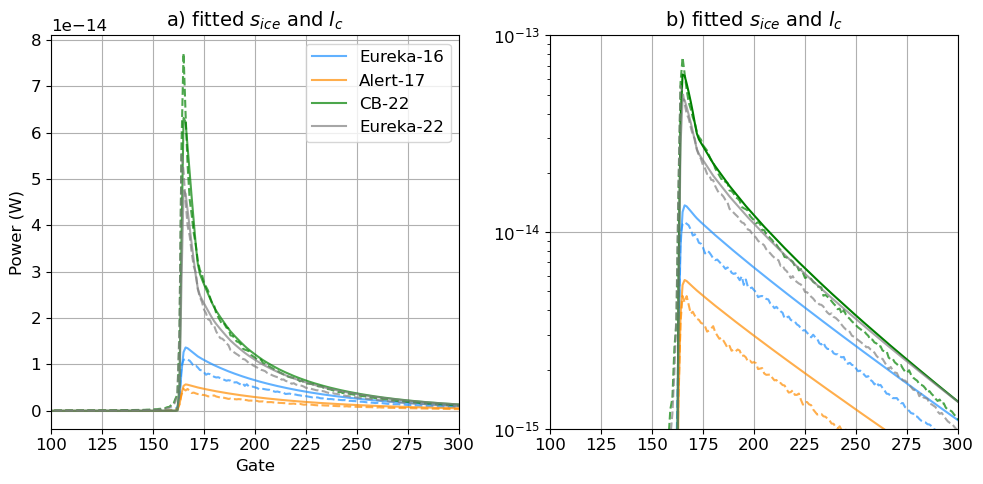

In [18]:
# Plot results
plt.close()
plt.rcParams.update({'font.size': 12})
fig, (ax1, ax2)  = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharex=True)

#Eureka normf roughness
ax1.plot(mean_simu_E_2 , color = 'dodgerblue', alpha = 0.7, label='Eureka-16')
ax1.plot(mean_obs_E, 'b-', linestyle = '--', color = 'dodgerblue', alpha = 0.7)

#Alert normf roughness 
ax1.plot(mean_simu_A_2, color = 'darkorange', alpha = 0.7, label='Alert-17')
ax1.plot(mean_obs_A, 'b-', linestyle = '--', color = 'darkorange', alpha = 0.7)

#CB normf roughness
ax1.plot(mean_simu_CB_1, color = 'green', alpha = 0.7, label='CB-22')
ax1.plot(mean_obs_CB, 'b-', linestyle = '--', color = 'green', alpha = 0.7)

#E22 normf roughness
ax1.plot(mean_simu_E22_1, color = 'grey', alpha = 0.7, label='Eureka-22')
ax1.plot(mean_obs_E22, 'b-', linestyle = '--', color = 'grey', alpha = 0.7)

ax1.set_ylabel('Power (W)', size = 12)
#ax1.set_yscale('log')
ax1.legend()
#ax1.set_xlim(0, 450)
# ax1.set_ylim(0, 1e-13)
ax1.grid()




#Eureka optimized roughness
ax2.plot(mean_simu_E_2, color = 'dodgerblue', alpha = 0.7)
ax2.plot(mean_obs_E, 'b-', linestyle = '--', color = 'dodgerblue', alpha = 0.7)

#Alert optimized roughness 
ax2.plot(mean_simu_A_2, color = 'darkorange', alpha = 0.7 )
ax2.plot(mean_obs_A, 'b-', linestyle = '--', color = 'darkorange', alpha = 0.7)

#CB optimized roughness
ax2.plot(mean_simu_CB_1, color = 'Green')
ax2.plot(mean_obs_CB, linestyle = '--', color = 'Green', alpha = 0.7)

#E22 optimized roughness
ax2.plot(mean_simu_E22_1, color = 'grey', alpha = 0.7, label='Eureka-22')
ax2.plot(mean_obs_E22, 'b-', linestyle = '--', color = 'grey', alpha = 0.7)

ax2.set_yscale('log')
ax2.grid()
ax2.set_ylim(1e-15, 1e-13)



ax1.set_title('a) fitted $s_{ice}$ and $l_c$ ', size = 14)
ax2.set_title('b) fitted $s_{ice}$ and $l_c$ ', size = 14)

ax1.set_xlabel('Gate')
ax1.set_xlabel('Gate')

ax1.set_xlim(100, 300)
plt.tight_layout()
# plt.savefig('/fs/homeu2/eccc/crd/ccrp/jum002/public_html/akross/sites_waveform_rough_opti.png', format='png', bbox_inches='tight')

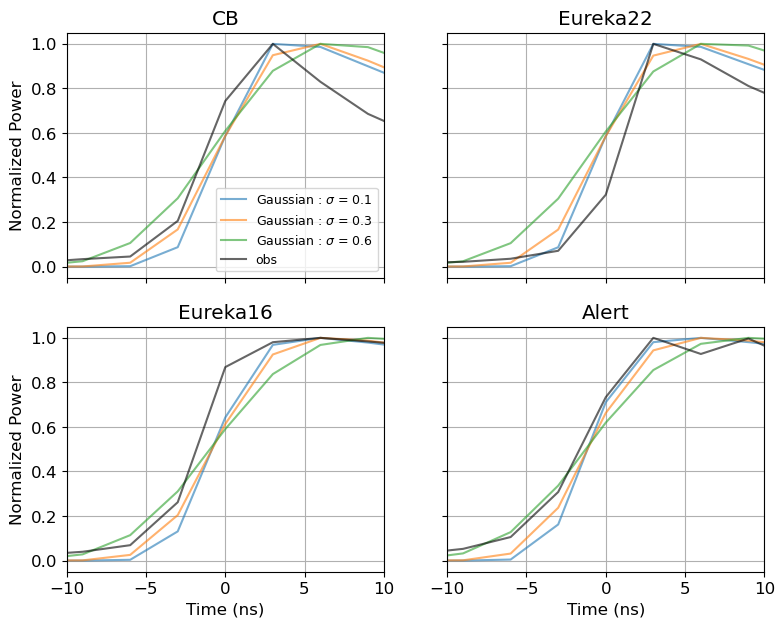

In [26]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (9,7), sharey = True, sharex = True)

ax1.plot(gate*3 - 164*3, mean_simu_CB_1/mean_simu_CB_1.max(), label = 'Gaussian : $\sigma$ = 0.1', alpha = 0.6,)
ax1.plot(gate*3 - 164*3, mean_simu_CB_2/mean_simu_CB_2.max(), label = 'Gaussian : $\sigma$ = 0.3', alpha = 0.6,)
ax1.plot(gate*3 - 164*3, mean_simu_CB_3/mean_simu_CB_3.max(), label = 'Gaussian : $\sigma$ = 0.6', alpha = 0.6,)

ax1.plot(gate*3 - 164*3,mean_obs_CB/mean_obs_CB.max(), label = 'obs', color = 'k', alpha = 0.6)
# ax1.set_xlim(-10,10)
ax1.legend(fontsize = 9)
ax1.grid()
ax1.set_title('CB')


ax2.plot(gate*3 - 164*3, mean_simu_E22_1/mean_simu_E22_1.max(), label = 'Gaussian : $\sigma$ = 0.1', alpha = 0.6,)
ax2.plot(gate*3 - 164*3, mean_simu_E22_2/mean_simu_E22_2.max(), label = 'Gaussian : $\sigma$ = 0.3', alpha = 0.6,)
ax2.plot(gate*3 - 164*3, mean_simu_E22_3/mean_simu_E22_3.max(), label = 'Gaussian : $\sigma$ = 0.6', alpha = 0.6,)

ax2.plot(gate*3 - 163*3,mean_obs_E22/mean_obs_E22.max(), label = 'obs', color = 'k', alpha = 0.6)
# ax2.set_xlim(-10,10)
ax2.grid()
ax2.set_title('Eureka22')



ax3.plot(gate*3 - 164*3, mean_simu_E_1/mean_simu_E_1.max(), label = 'Gaussian : $\sigma$ = 0.1', alpha = 0.6,)
ax3.plot(gate*3 - 164*3, mean_simu_E_2/mean_simu_E_2.max(), label = 'Gaussian : $\sigma$ = 0.3', alpha = 0.6,)
ax3.plot(gate*3 - 164*3, mean_simu_E_3/mean_simu_E_3.max(), label = 'Gaussian : $\sigma$ = 0.6', alpha = 0.6,)

ax3.plot(gate*3 - 164*3,mean_obs_E/mean_obs_E.max(), label = 'obs', color = 'k', alpha = 0.6)
# ax3.set_xlim(-10,10)
ax3.grid()
ax3.set_title('Eureka16')


ax4.plot(gate*3 - 164*3, mean_simu_A_1/mean_simu_A_1.max(), label = 'Gaussian : $\sigma$ = 0.1', alpha = 0.6,)
ax4.plot(gate*3 - 164*3, mean_simu_A_2/mean_simu_A_2.max(), label = 'Gaussian : $\sigma$ = 0.3', alpha = 0.6,)
ax4.plot(gate*3 - 164*3, mean_simu_A_3/mean_simu_A_3.max(), label = 'Gaussian : $\sigma$ = 0.6', alpha = 0.6,)

ax4.plot(gate*3 - 164*3,mean_obs_A/mean_obs_A.max(), label = 'obs', color = 'k', alpha = 0.6)
ax4.set_xlim(-10,10)
ax4.grid()
ax4.set_title('Alert')

ax1.set_ylabel('Normalized Power')
ax3.set_ylabel('Normalized Power')
ax3.set_xlabel('Time (ns)')
ax4.set_xlabel('Time (ns)')
fig.savefig('/fs/homeu3/eccc/crd/cps/jum002/public_html/akross/fit_sigma_surf.png')


In [ ]:
def lrm_sigma_surface(sigma_surface):
    CB_sp = AK.build_snowpack_pickle(list_profile_E22, ice_salinity = 10, ice_temp = 260, sea_ice_density = 910, 
                                    ice_type = 'firstyear', sigma_surface= sigma_surface)

    altimodel = make_model(derived_IBA(ssp), "nadir_lrm_altimetry", rtsolver_options=dict(theta_inc_sampling=64),
                                emmodel_options=dict(dense_snow_correction="auto"))
    cryosat = altimeter_list.cryosat2_sin()
    # res = altimodel.run(cryosat, sp, parallel_computation=False).sigma()
    res = altimodel.run(cryosat, CB_sp, parallel_computation=True).sigma().mean(dim = 'snowpack')

    return res.values

0.01
0.128
0.246
0.364
0.482
0.6


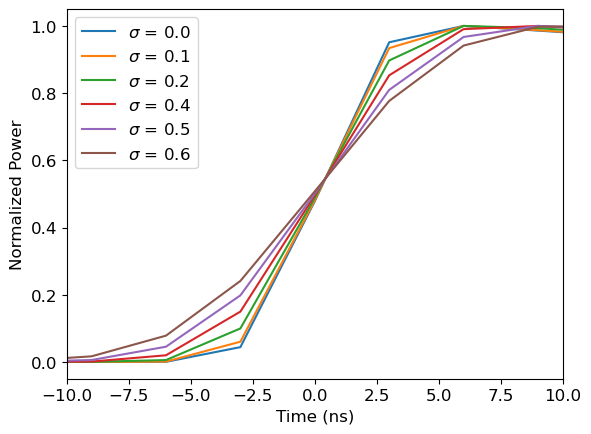

In [ ]:
sig_surf = np.linspace(0.01, 0.6, 6)
time = gate.values*3
fig, ax = plt.subplots(1,1, )

for sig in sig_surf:
    print(sig)
    lrm = lrm_sigma_surface(sig)
    ax.plot(time -164*3, lrm/lrm.max(), label = f'$\sigma$ = {np.round(sig,1)}')

ax.set_xlim(-10,10)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Normalized Power')
plt.legend()
fig.savefig('/fs/homeu2/eccc/crd/ccrp/jum002/public_html/akross/waveform_sigma_surf.png')